In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# 1. 强制安装 d2l，但不安装它的依赖项
!pip install d2l --no-deps

# 2. 手动安装 d2l 必须但 Kaggle 可能没对齐的少量库（通常不需要，可以先试第一步）
# !pip install jupyter  # 如果报错找不到 jupyter 再运行这行

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.7/111.7 kB 3.4 MB/s eta 0:00:00


In [3]:
import torch
from torch import nn
from d2l import torch as d2l

def conv_block(in_channels, num_channels):
    return nn.Sequential(
        nn.BatchNorm2d(in_channels),
        nn.ReLU(),
        nn.Conv2d(in_channels, num_channels, kernel_size=3, padding=1)
    )

class DenseBlock(nn.Module):
    def __init__(self, nums_convs, in_channels, nums_channels):
        super(DenseBlock,self).__init__()
        self.net = nn.Sequential()
        layer=[]
        for i in range(nums_convs):
            layer.append(conv_block(nums_channels*i+in_channels, nums_channels)) 
            # 每个卷积层的输入通道数是初始输入通道数加上前面卷积层输出通道数的总和，因为前面所有卷积层的输出都被连接到这里了
        self.net = nn.Sequential(*layer)

    def forward(self, X):
        for blk in self.net:
            Y = blk(X)
            X = torch.cat((X, Y), dim=1)  # 在通道维上将输入和输出连接起来
        return X
    # 每次卷积层的输出都与输入连接起来，这样后续的卷积层就可以利用前面所有卷积层的输出特征

blk = DenseBlock(10, 3, 10)
X = torch.randn(4, 3, 8, 8)
Y = blk(X)
print(Y.shape)
# torch.Size([4, 103, 8, 8]) 
# 因为每个卷积层输出10个通道，十个卷积层总共输出100个通道，加上初始输入的3个通道，总共是103个通道。
# 具体来说，第一次卷积层输出10个通道，第二次卷积层输入是初始的3个通道加上第一次卷积层的10个通道，总共13个通道，第二次卷积层输出10个通道，所以总共是3（初始输入） + 10（第一次卷积层输出） + 10（第二次卷积层输出） + ... = 103个通道。

# 过渡层：在两个密集块之间添加过渡层来控制模型复杂度和过拟合。
# 过渡层通常由一个1x1卷积层和一个2x2平均池化层组成，用于减少通道数和空间尺寸。
def transition_block(input_channels, num_channels):
    return nn.Sequential(
        nn.BatchNorm2d(input_channels), nn.ReLU(),
        nn.Conv2d(input_channels, num_channels, kernel_size=1),
        nn.AvgPool2d(kernel_size=2, stride=2))

blk = transition_block(103, 10)
print(blk(Y).shape) # torch.Size([4, 10, 4, 4])
# 其中输入通道数是103，输出通道数是10，过渡层的1x1卷积层将通道数从103减少到10。
# 空间尺寸从8x8变为4x4，平均池化层将空间尺寸减半。

torch.Size([4, 103, 8, 8])
torch.Size([4, 10, 4, 4])


In [4]:
b1 = nn.Sequential(
    nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3),
    nn.BatchNorm2d(64), nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

In [5]:
# num_channels为当前的通道数
num_channels, growth_rate = 64, 32
num_convs_in_dense_blocks = [4, 4, 4, 4]
blks = []
for i, num_convs in enumerate(num_convs_in_dense_blocks):
    blks.append(DenseBlock(num_convs, num_channels, growth_rate))
    # 上一个稠密块的输出通道数
    num_channels += num_convs * growth_rate
    # 在稠密块之间添加一个转换层，使通道数量减半
    if i != len(num_convs_in_dense_blocks) - 1:
        blks.append(transition_block(num_channels, num_channels // 2))
        num_channels = num_channels // 2

In [6]:
net = nn.Sequential(
    b1, *blks,
    nn.BatchNorm2d(num_channels), nn.ReLU(),
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(num_channels, 10))

loss 0.138, train acc 0.949, test acc 0.888
1893.6 examples/sec on cuda:0


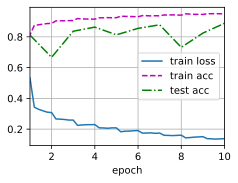

In [7]:
lr, num_epochs, batch_size = 0.1, 10, 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size, resize=96)
d2l.train_ch6(net, train_iter, test_iter, num_epochs, lr, d2l.try_gpu())